In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [7]:
df =  pd.read_csv("solar_system.csv")
print(df.shape)
print(df.head())
print(df.tail())
print(df.columns)
print(df.index)

(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring Sy

In [11]:
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)

print(orbital_period)
print(perihelion)
print(aphelion)

Mercury       88.0
Venus        224.7
Earth        365.2
Moon          27.3
Mars         687.0
Jupiter     4331.0
Saturn     10747.0
Uranus     30589.0
Neptune    59800.0
Pluto      90560.0
Name: 10, dtype: float64
Mercury      46.000
Venus       107.500
Earth       147.100
Moon          0.363
Mars        206.700
Jupiter     740.600
Saturn     1357.600
Uranus     2732.700
Neptune    4471.100
Pluto      4436.800
Name: 8, dtype: float64
Mercury      69.800
Venus       108.900
Earth       152.100
Moon          0.406
Mars        249.300
Jupiter     816.400
Saturn     1506.500
Uranus     3001.400
Neptune    4558.900
Pluto      7375.900
Name: 9, dtype: float64


In [ ]:
#perihelion is the closest point to the sun in an elliptical orbit
#aphelion is the farthest point to the sun in an elliptical orbit
#the semimajor axis is half of the longest diameter of an ellipse

In [16]:
semi_major_axis = (perihelion + aphelion) / 2

new_row = {'Attribute': 'Semi-major Axis'}
new_row.update(semi_major_axis.to_dict())

new_df = pd.DataFrame([new_row])
df = pd.concat([df, new_df], ignore_index=True)

#9
print(df.shape)
print(df.shape[0])
print(df.shape[1])

(23, 11)
23
11


Fitted Model: T = 0.20 * a^1.5


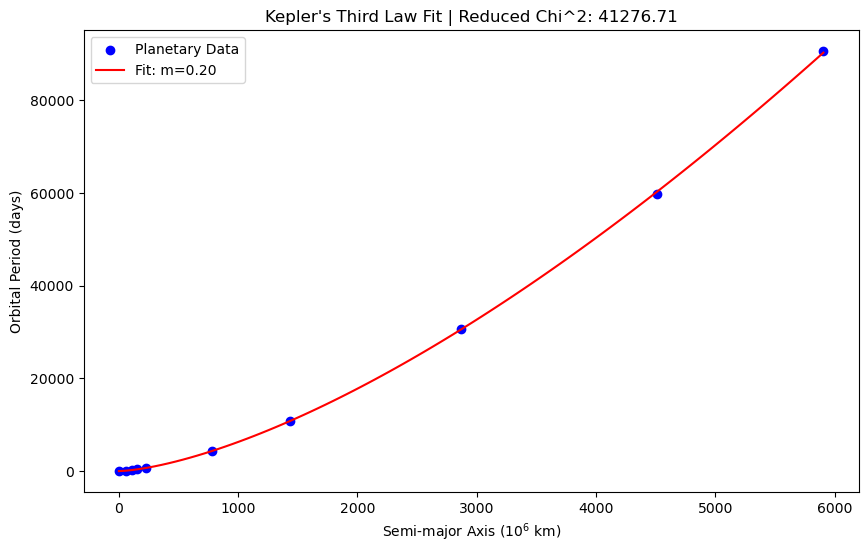

In [27]:
#10
plt.figure(figsize=(10, 6))
plt.scatter(semi_major_axis, orbital_period, color='blue', label='Planetary Data')

#11
def keplers_third_law(a, m):
    return m * a**1.5

#12
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)

#13 
m_fit = popt[0]

#14
print(f"Fitted Model: T = {m_fit:.2f} * a^1.5")

#15
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(orbital_period) - len(popt)
chi2_reduced = chi2 / dof

#16
plt.plot(a_smooth, keplers_third_law(a_smooth, m_fit), color='red', label=f'Fit: m={m_fit:.2f}')
plt.xlabel("Semi-major Axis ($10^6$ km)")
plt.ylabel("Orbital Period (days)")
plt.title(f"Kepler's Third Law Fit | Reduced Chi^2: {chi2_reduced:.2f}")
plt.legend()
plt.show()